천수방정식(얕은 물 방정식, shallow water equation)의 간략한 Python 코드

gemini 버전

In [2]:
import numpy as np

def solve_shallow_water(grid_size, total_time, dt):
    """
    얕은 물 방정식(천수방정식)을 계산하여 물의 움직임을 시뮬레이션하는 함수입니다.

    Args:
        grid_size (int): 계산할 공간의 격자 크기입니다 (예: 100은 100x100 격자를 의미합니다).
        total_time (float): 시뮬레이션을 진행할 총 시간(초)입니다.
        dt (float): 시간을 얼마나 잘게 나눌지에 대한 시간 간격(초)입니다.
    """

    # --- 1. 시뮬레이션 환경 준비 ---

    g = 9.8  # 중력가속도(m/s^2)를 정의합니다.

    # 계산에 사용할 격자(grid)를 생성합니다.
    # 각 격자 지점의 물 높이(h), x방향 유속(u), y방향 유속(v)을 저장할 배열을 준비합니다.
    h = np.ones((grid_size, grid_size))  # 물의 높이 배열을 생성하고, 초기 높이를 1로 설정합니다.
    u = np.zeros((grid_size, grid_size)) # x방향(좌우) 유속 배열을 생성하고, 초기 유속을 0으로 설정합니다.
    v = np.zeros((grid_size, grid_size)) # y방향(상하) 유속 배열을 생성하고, 초기 유속을 0으로 설정합니다.

    # --- 2. 초기 조건 설정: 중앙에 물방울 생성 ---

    # 격자 중앙에 물방울이 떨어진 효과를 생성합니다.
    center_x, center_y = grid_size // 2, grid_size // 2  # 격자의 중앙 좌표를 계산합니다.
    radius = grid_size // 8  # 물방울의 반지름 크기를 설정합니다.

    # 모든 격자 지점을 순회합니다.
    for i in range(grid_size):
        for j in range(grid_size):
            # 각 지점과 중앙 사이의 거리를 계산합니다.
            dist = np.sqrt((i - center_x)**2 + (j - center_y)**2)
            # 거리가 반지름보다 작으면 (원 안쪽이면)
            if dist < radius:
                # 해당 지점의 물 높이를 2로 설정하여 초기 파동을 만듭니다.
                h[i, j] = 2.0

    # --- 3. 시간에 따른 변화 계산 (메인 루프) ---

    # 설정된 총 시간이 될 때까지 시간 간격(dt)만큼씩 반복하여 계산합니다.
    for t in np.arange(0, total_time, dt):
        # 다음 시간 단계의 값을 저장하기 위한 임시 배열을 복사하여 생성합니다.
        h_new = np.copy(h)
        u_new = np.copy(u)
        v_new = np.copy(v)

        # 경계 조건을 제외한 내부 격자 전체에 대해 계산을 반복합니다.
        for i in range(1, grid_size - 1):
            for j in range(1, grid_size - 1):

                # --- 천수방정식의 핵심 계산 부분 ---

                # (1) 질량 보존: 주변 격자와의 물 유출입량을 계산하여 수면 높이(h)의 변화를 계산합니다.
                # 'h * u'는 단위 시간당 격자 경계를 통과하는 물의 양(유량)을 의미합니다.
                du_dx = (h[i+1, j] * u[i+1, j] - h[i-1, j] * u[i-1, j]) / 2.0 # x방향 유량의 변화율입니다.
                dv_dy = (h[i, j+1] * v[i, j+1] - h[i, j-1] * v[i, j-1]) / 2.0 # y방향 유량의 변화율입니다.
                h_new[i, j] = h[i, j] - dt * (du_dx + dv_dy) # 현재 높이에서 유량 변화량만큼 높이를 조절합니다.

                # (2) 운동량 보존 (x방향): 수면 경사와 유속 변화에 따라 x방향 유속(u)의 변화를 계산합니다.
                dh_dx = (h[i+1, j] - h[i-1, j]) / 2.0 # x방향 수면의 기울기입니다.
                u_advection = u[i, j] * (u[i+1, j] - u[i-1, j]) / 2.0 # x방향 이류항(흐름 자체에 의한 속도 변화)입니다.
                v_advection = v[i, j] * (u[i, j+1] - u[i, j-1]) / 2.0 # y방향 흐름이 x방향 유속에 미치는 영향입니다.
                u_new[i, j] = u[i, j] - dt * (g * dh_dx + u_advection + v_advection) # 중력과 이류항의 영향을 반영하여 유속을 업데이트합니다.

                # (3) 운동량 보존 (y방향): y방향 유속(v)의 변화를 계산합니다.
                dh_dy = (h[i, j+1] - h[i, j-1]) / 2.0 # y방향 수면의 기울기입니다.
                u_advection_v = u[i, j] * (v[i+1, j] - v[i-1, j]) / 2.0
                v_advection_v = v[i, j] * (v[i, j+1] - v[i, j-1]) / 2.0
                v_new[i, j] = v[i, j] - dt * (g * dh_dy + u_advection_v + v_advection_v) # 중력과 이류항의 영향을 반영하여 유속을 업데이트합니다.

        # 모든 내부 격자에 대한 계산이 끝나면, 새로운 값으로 전체 배열을 업데이트합니다.
        h = h_new
        u = u_new
        v = v_new

    # 최종적으로 계산된 물의 높이 배열을 반환합니다.
    return h

# --- 함수 사용 예시 ---
# 100x100 크기 격자에서 5초 동안, 0.01초 간격으로 시뮬레이션 실행
# final_water_height = solve_shallow_water(grid_size=100, total_time=5.0, dt=0.01)

시각화

'shallow_water_animation.gif' 파일로 애니메이션을 저장 중입니다... 시간이 걸릴 수 있습니다.
'shallow_water_animation.gif' 파일 저장이 완료되었습니다.


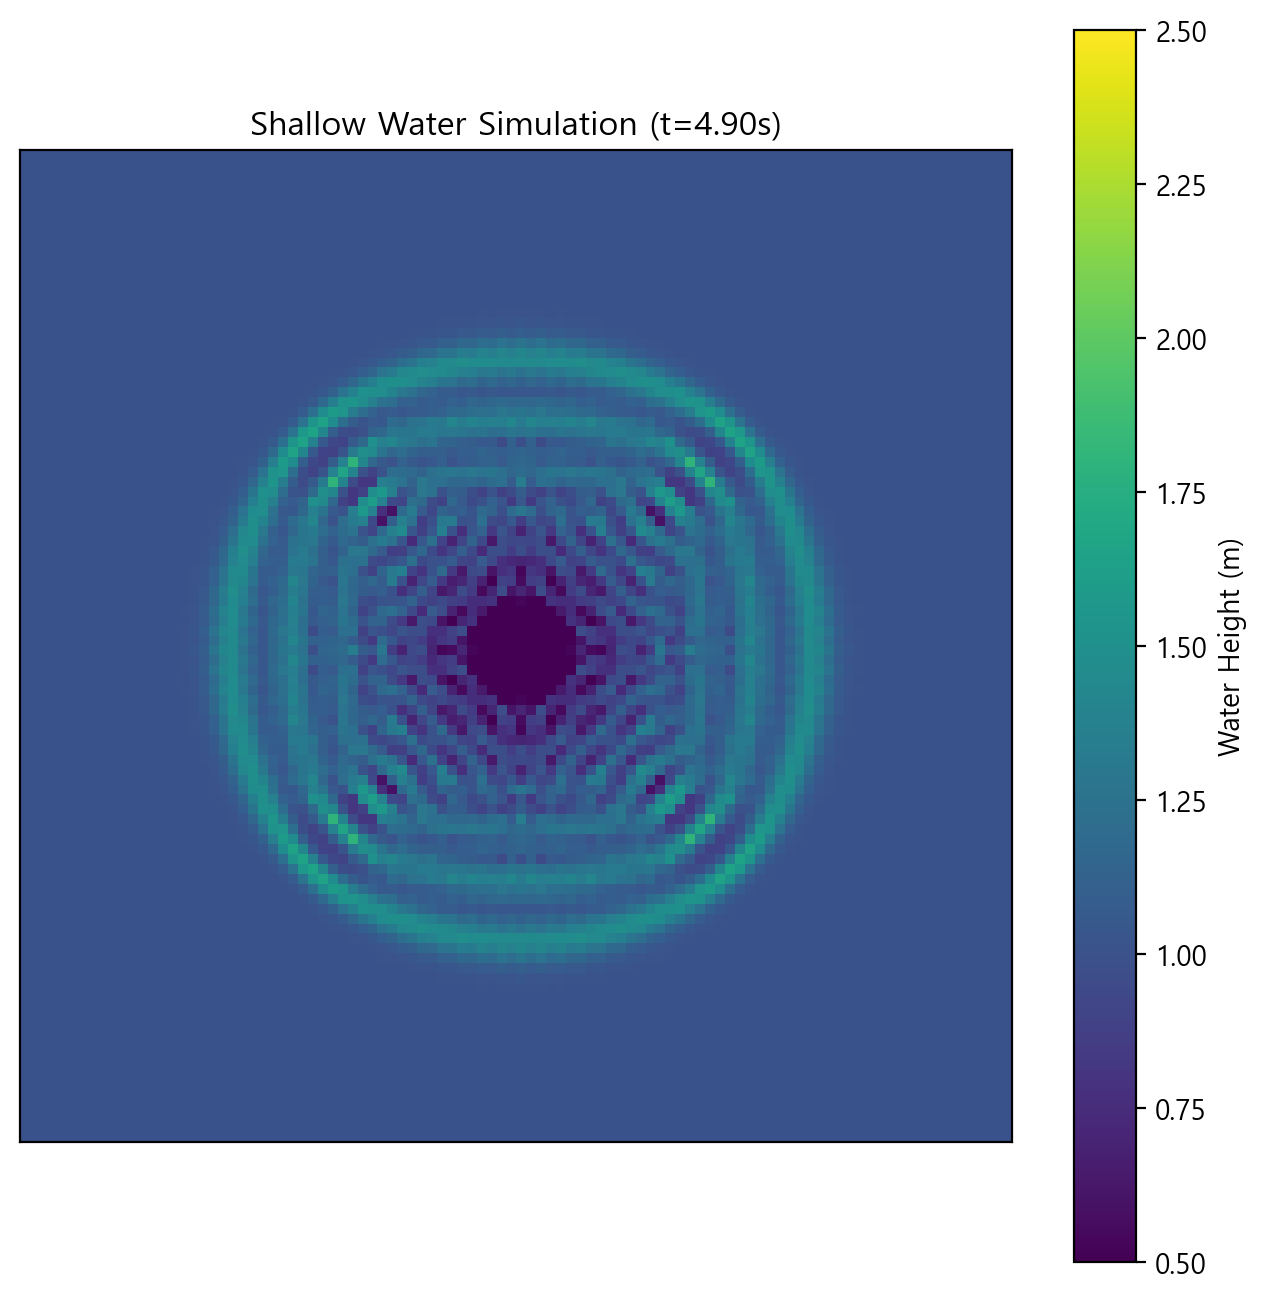

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def solve_shallow_water_and_save_gif(grid_size, total_time, dt, filename="shallow_water_animation.gif"):
    """
    얕은 물 방정식(천수방정식)을 계산하고, 그 결과를 GIF 애니메이션 파일로 저장하는 함수입니다.

    Args:
        grid_size (int): 계산할 공간의 격자 크기입니다 (예: 100은 100x100 격자를 의미합니다).
        total_time (float): 시뮬레이션을 진행할 총 시간(초)입니다.
        dt (float): 시간을 얼마나 잘게 나눌지에 대한 시간 간격(초)입니다.
        filename (str): 저장할 GIF 파일의 이름입니다.
    """

    # --- 1. 시뮬레이션 환경 준비 ---
    g = 9.8  # 중력가속도(m/s^2)를 정의합니다.
    h = np.ones((grid_size, grid_size))
    u = np.zeros((grid_size, grid_size))
    v = np.zeros((grid_size, grid_size))

    # --- 2. 초기 조건 설정: 중앙에 물방울 생성 ---
    center_x, center_y = grid_size // 2, grid_size // 2
    radius = grid_size // 8
    for i in range(grid_size):
        for j in range(grid_size):
            dist = np.sqrt((i - center_x)**2 + (j - center_y)**2)
            if dist < radius:
                h[i, j] = 2.0

    # --- 3. 시각화 준비 ---
    fig, ax = plt.subplots(figsize=(8, 8))
    img = ax.imshow(h, cmap='viridis', vmin=0.5, vmax=2.5)
    fig.colorbar(img, ax=ax, label='Water Height (m)')
    ax.set_title("Shallow Water Simulation (t=0.00s)")
    ax.set_xticks([])
    ax.set_yticks([])

    # 애니메이션의 각 프레임을 업데이트하는 함수입니다.
    def update(frame):
        nonlocal h, u, v
        
        # 10 프레임마다 한 번씩 계산을 수행하여 애니메이션 속도를 조절합니다.
        for _ in range(10):
            h_new = np.copy(h)
            u_new = np.copy(u)
            v_new = np.copy(v)

            for i in range(1, grid_size - 1):
                for j in range(1, grid_size - 1):
                    # (1) 질량 보존
                    du_dx = (h[i+1, j] * u[i+1, j] - h[i-1, j] * u[i-1, j]) / 2.0
                    dv_dy = (h[i, j+1] * v[i, j+1] - h[i, j-1] * v[i, j-1]) / 2.0
                    h_new[i, j] = h[i, j] - dt * (du_dx + dv_dy)

                    # (2) 운동량 보존 (x방향)
                    dh_dx = (h[i+1, j] - h[i-1, j]) / 2.0
                    u_advection = u[i, j] * (u[i+1, j] - u[i-1, j]) / 2.0
                    v_advection = v[i, j] * (u[i, j+1] - u[i, j-1]) / 2.0
                    u_new[i, j] = u[i, j] - dt * (g * dh_dx + u_advection + v_advection)

                    # (3) 운동량 보존 (y방향)
                    dh_dy = (h[i, j+1] - h[i, j-1]) / 2.0
                    u_advection_v = u[i, j] * (v[i+1, j] - v[i-1, j]) / 2.0
                    v_advection_v = v[i, j] * (v[i, j+1] - v[i, j-1]) / 2.0
                    v_new[i, j] = v[i, j] - dt * (g * dh_dy + u_advection_v + v_advection_v)

            h, u, v = h_new, u_new, v_new

        img.set_array(h)
        current_time = frame * dt * 10
        ax.set_title(f"Shallow Water Simulation (t={current_time:.2f}s)")
        return [img]

    # --- 4. 애니메이션 생성 및 저장 ---
    num_frames = int(total_time / (dt * 10))
    ani = animation.FuncAnimation(fig, update, frames=num_frames, blit=True, interval=20)

    # 애니메이션을 GIF 파일로 저장합니다.
    # pillow 라이브러리가 GIF를 만드는 역할을 합니다. fps는 초당 프레임 수입니다.
    print(f"'{filename}' 파일로 애니메이션을 저장 중입니다... 시간이 걸릴 수 있습니다.")
    ani.save(filename, writer='pillow', fps=15)
    print(f"'{filename}' 파일 저장이 완료되었습니다.")
    
    # 현재 환경에서는 그래프 창을 보여줄 수 없으므로 plt.show() 대신 저장을 사용합니다.
    # plt.show()

# --- 함수 사용 예시 ---
# 100x100 크기 격자에서 5초 동안, 0.01초 간격으로 시뮬레이션 실행 및 GIF 저장
solve_shallow_water_and_save_gif(grid_size=100, total_time=5.0, dt=0.01)


gpt 버전

In [1]:
import numpy as np

# 천수 방정식을 계산하는 함수
# 천수 방정식은 물의 흐름과 높이를 나타내는 방정식입니다.
def shallow_water_equation(h, u, v, g=9.8, dt=0.1):
    # h: 물의 높이 (2차원 배열)
    # u: x축 방향으로의 물의 속도 (2차원 배열)
    # v: y축 방향으로의 물의 속도 (2차원 배열)
    # g: 중력 가속도
    # dt: 시간 간격

    # 물의 높이가 변하는 정도를 계산합니다.
    dh = -h * (np.gradient(u, axis=1) + np.gradient(v, axis=0))

    # x축 방향의 속도가 변하는 정도를 계산합니다.
    du = -g * np.gradient(h, axis=1) - u * np.gradient(u, axis=1) - v * np.gradient(u, axis=0)

    # y축 방향의 속도가 변하는 정도를 계산합니다.
    dv = -g * np.gradient(h, axis=0) - u * np.gradient(v, axis=1) - v * np.gradient(v, axis=0)

    # 새로운 물의 높이와 속도를 계산합니다.
    h_new = h + dh * dt
    u_new = u + du * dt
    v_new = v + dv * dt

    # 계산된 새로운 높이와 속도를 반환합니다.
    return h_new, u_new, v_new


# 예시: 간단한 초기 조건을 만들어 천수 방정식 계산하기
h = np.ones((5, 5))  # 물 높이를 모두 1로 초기화
u = np.zeros((5, 5))  # x축 방향의 속도는 0
v = np.zeros((5, 5))  # y축 방향의 속도는 0

# 가운데 위치한 물의 높이를 조금 높게 설정해서 물결을 만들어 봅니다.
h[2, 2] = 2

# 천수 방정식으로 물의 움직임을 계산합니다.
h, u, v = shallow_water_equation(h, u, v)

# 결과를 출력합니다.
print("새로운 물의 높이:\n", h)
print("새로운 x축 속도:\n", u)
print("새로운 y축 속도:\n", v)


새로운 물의 높이:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 2. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
새로운 x축 속도:
 [[ 0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.   -0.49  0.    0.49  0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]]
새로운 y축 속도:
 [[ 0.    0.    0.    0.    0.  ]
 [ 0.    0.   -0.49  0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.49  0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]]


In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rc('font', family='Malgun Gothic') #한글 폰트 적용시   #Malgun Gothic  NanumGothic
plt.rcParams["figure.figsize"] = (16,4.5) #차트 사이즈
plt.rcParams['axes.unicode_minus'] = False

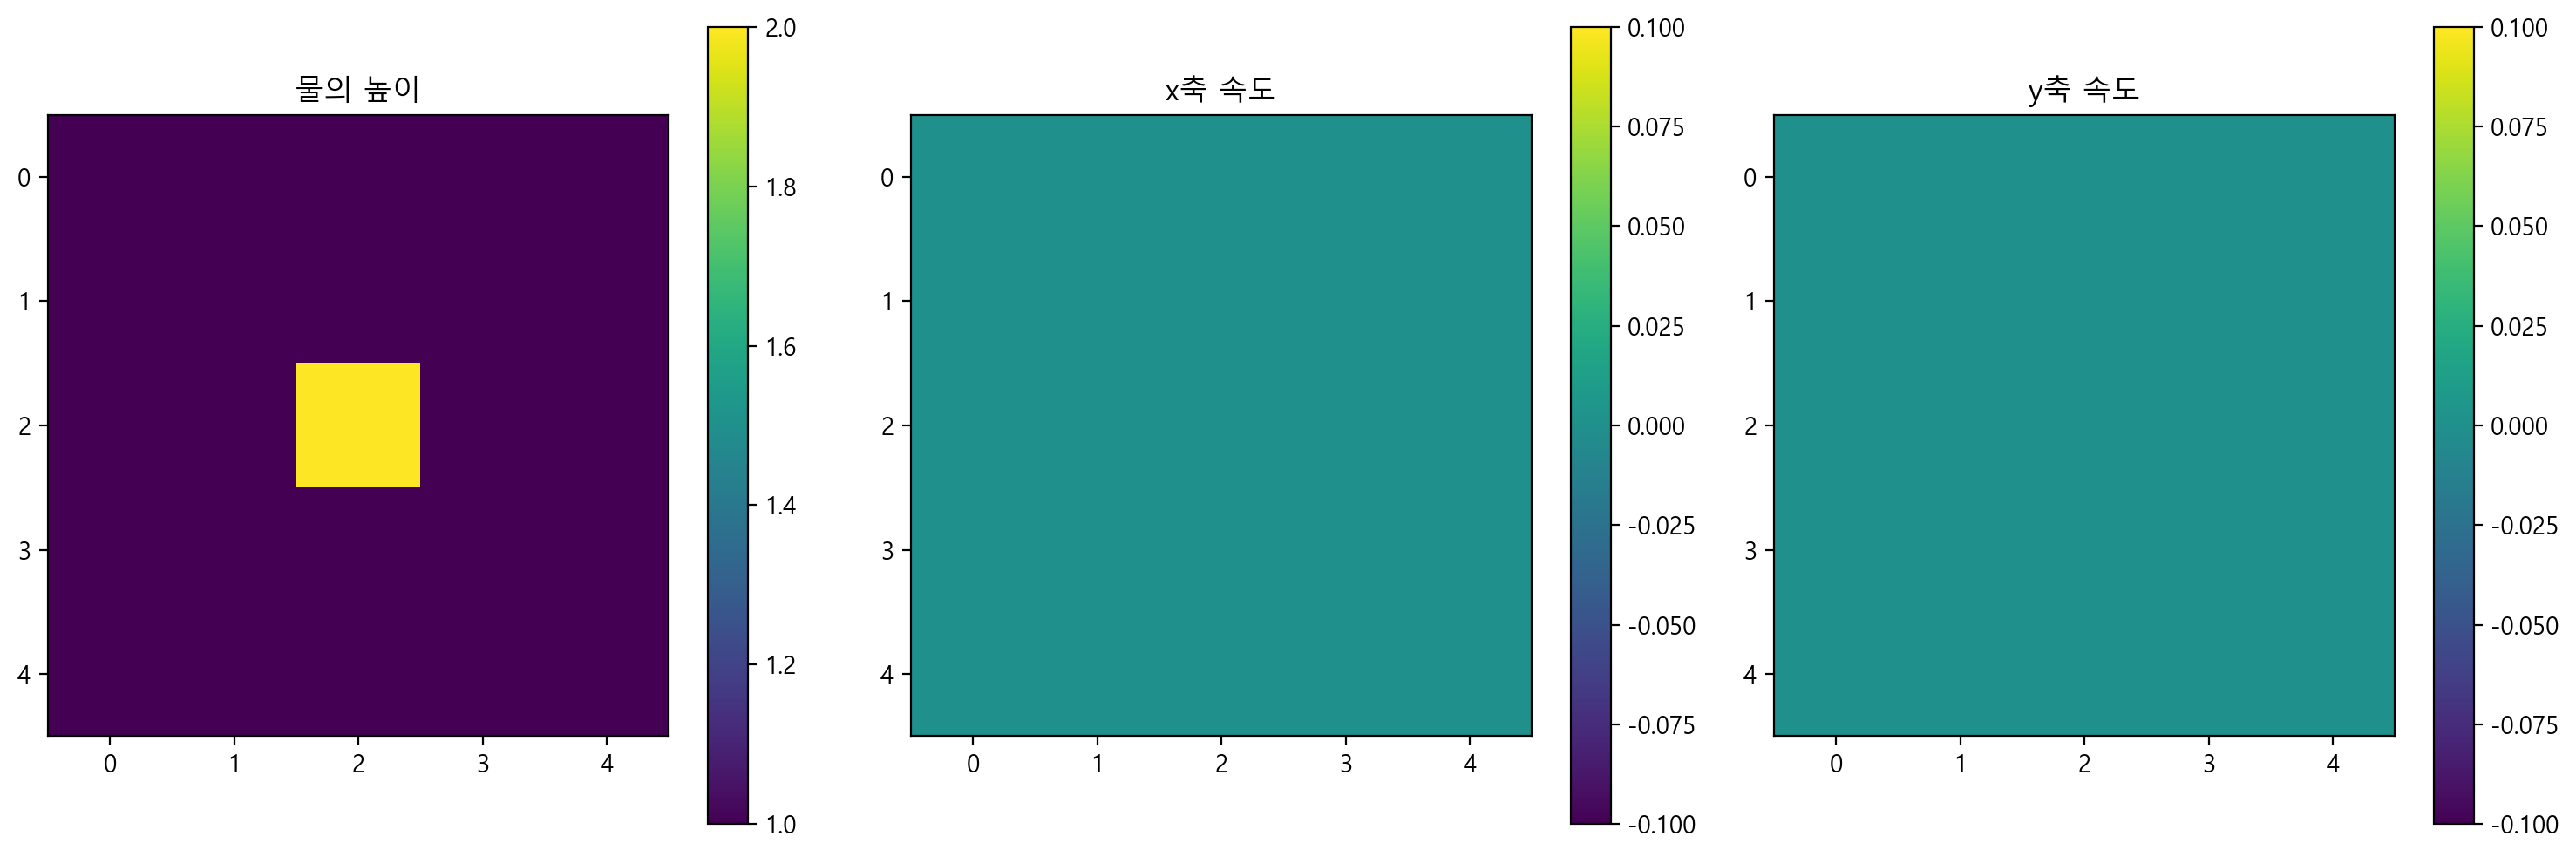

In [7]:
# 천수 방정식을 계산하는 함수
# 천수 방정식은 물의 흐름과 높이를 나타내는 방정식입니다.
def shallow_water_equation(h, u, v, g=9.8, dt=0.1):
    # h: 물의 높이 (2차원 배열)
    # u: x축 방향으로의 물의 속도 (2차원 배열)
    # v: y축 방향으로의 물의 속도 (2차원 배열)
    # g: 중력 가속도
    # dt: 시간 간격

    # 물의 높이가 변하는 정도를 계산합니다.
    dh = -h * (np.gradient(u, axis=1) + np.gradient(v, axis=0))

    # x축 방향의 속도가 변하는 정도를 계산합니다.
    du = -g * np.gradient(h, axis=1) - u * np.gradient(u, axis=1) - v * np.gradient(u, axis=0)

    # y축 방향의 속도가 변하는 정도를 계산합니다.
    dv = -g * np.gradient(h, axis=0) - u * np.gradient(v, axis=1) - v * np.gradient(v, axis=0)

    # 새로운 물의 높이와 속도를 계산합니다.
    h_new = h + dh * dt
    u_new = u + du * dt
    v_new = v + dv * dt

    # 계산된 새로운 높이와 속도를 반환합니다.
    return h_new, u_new, v_new


# 예시: 간단한 초기 조건을 만들어 천수 방정식 계산하기
h = np.ones((5, 5))  # 물 높이를 모두 1로 초기화
u = np.zeros((5, 5))  # x축 방향의 속도는 0
v = np.zeros((5, 5))  # y축 방향의 속도는 0

# 가운데 위치한 물의 높이를 조금 높게 설정해서 물결을 만들어 봅니다.
h[2, 2] = 2

# 천수 방정식으로 물의 움직임을 계산하고 시각화하기
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["물의 높이", "x축 속도", "y축 속도"]
data = [h, u, v]

# 초기 상태 시각화
for i in range(3):
    ax = axes[i]
    im = ax.imshow(data[i], cmap='viridis', interpolation='none')
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


### 저수지 붕괴 응용 코드

### gemini 버전

In [ ]:
import numpy as np

def simulate_dam_breach(dem_data, breach_location, total_water_volume, total_time, dt):
    """
    DEM(디지털 고도 모델) 지형 데이터 위에서 저수지 붕괴를 가정하고,
    천수방정식을 이용해 하류부의 침수 영역을 시뮬레이션하는 함수입니다.

    Args:
        dem_data (np.array): 땅의 높이(고도) 정보를 담고 있는 2D numpy 배열입니다.
        breach_location (tuple): 저수지 붕괴가 시작되는 지점의 (x, y) 좌표입니다.
        total_water_volume (float): 저수지에서 방출되는 물의 총량(체적, m^3)입니다.
        total_time (float): 시뮬레이션을 진행할 총 시간(초)입니다.
        dt (float): 계산에 사용할 시간 간격(time step, 초)입니다. 작을수록 정확도가 높아집니다.

    Returns:
        np.array: 각 격자(셀)별 최대 침수 깊이(m)를 기록한 2D numpy 배열을 반환합니다.
    """

    # --- 1. 시뮬레이션 환경 설정 ---

    g = 9.8  # 중력가속도 (m/s^2)입니다.
    grid_size_x, grid_size_y = dem_data.shape # DEM 데이터로부터 격자 크기를 가져옵니다.
    dx, dy = 10.0, 10.0 # 각 격자의 실제 가로, 세로 길이를 10m로 가정합니다.

    # 지형(땅 높이), 수면 높이, 유속(x, y 방향)을 저장할 배열을 준비합니다.
    dem = np.copy(dem_data) # 땅의 높이(고도) 배열입니다.
    h = np.copy(dem)        # 수면의 절대 높이(해발고도) 배열입니다. 처음에는 물이 없으므로 땅 높이와 같습니다.
    u = np.zeros_like(dem)  # x방향(좌우) 유속 배열입니다.
    v = np.zeros_like(dem)  # y방향(상하) 유속 배열입니다.

    # 시뮬레이션 시간 동안 각 지점의 최대 침수 깊이를 기록할 배열을 준비합니다.
    max_depth = np.zeros_like(dem)

    # --- 2. 초기 조건 설정: 저수지 붕괴 ---

    breach_x, breach_y = breach_location # 붕괴 지점 좌표를 가져옵니다.
    # 붕괴 지점에 저수지의 총 수량을 추가하여 수면을 급격히 높입니다.
    # (물의 체적을 격자 면적으로 나누어 해당 지점의 수심 증가량을 계산)
    h[breach_x, breach_y] += total_water_volume / (dx * dy)

    # --- 3. 시간에 따른 변화 계산 (메인 루프) ---

    for t in np.arange(0, total_time, dt):
        # 다음 시간 단계의 값을 저장하기 위한 임시 배열을 복사하여 생성합니다.
        h_new = np.copy(h)
        u_new = np.copy(u)
        v_new = np.copy(v)

        # 경계 조건을 제외한 내부 격자 전체에 대해 계산을 반복합니다.
        for i in range(1, grid_size_x - 1):
            for j in range(1, grid_size_y - 1):

                # 현재 지점(i, j)의 수심을 계산합니다. (수면 높이 - 땅 높이)
                # 수심이 0보다 작으면 0으로 처리합니다 (마른 땅).
                depth = max(0, h[i, j] - dem[i, j])
                if depth <= 1e-4: # 수심이 매우 얕으면 흐름이 없다고 간주하여 계산을 건너뜁니다.
                    continue

                # --- 천수방정식의 핵심 계산 부분 ---

                # (1) 질량 보존: 주변 격자와의 물 유출입량을 계산하여 수면 높이(h)의 변화를 계산합니다.
                # hu, hv는 각각 x, y 방향의 유량(flux)을 의미합니다.
                flux_u_right = max(0, h[i+1, j] - dem[i+1, j]) * u[i+1, j]
                flux_u_left = max(0, h[i-1, j] - dem[i-1, j]) * u[i-1, j]
                flux_v_up = max(0, h[i, j+1] - dem[i, j+1]) * v[i, j+1]
                flux_v_down = max(0, h[i, j-1] - dem[i, j-1]) * v[i, j-1]

                du_dx = (flux_u_right - flux_u_left) / (2.0 * dx)
                dv_dy = (flux_v_up - flux_v_down) / (2.0 * dy)
                h_new[i, j] = h[i, j] - dt * (du_dx + dv_dy)

                # (2) 운동량 보존 (x방향): 수면 경사와 유속 변화에 따라 x방향 유속(u)의 변화를 계산합니다.
                dh_dx = (h[i+1, j] - h[i-1, j]) / (2.0 * dx) # x방향 수면 경사
                u_advection = u[i, j] * (u[i+1, j] - u[i-1, j]) / (2.0 * dx) # 이류항 (흐름 자체에 의한 속도 변화)
                v_advection = v[i, j] * (u[i, j+1] - u[i, j-1]) / (2.0 * dy)
                u_new[i, j] = u[i, j] - dt * (g * dh_dx + u_advection + v_advection)

                # (3) 운동량 보존 (y방향): y방향 유속(v)의 변화를 계산합니다.
                dh_dy = (h[i, j+1] - h[i, j-1]) / (2.0 * dy) # y방향 수면 경사
                u_advection_v = u[i, j] * (v[i+1, j] - v[i-1, j]) / (2.0 * dx)
                v_advection_v = v[i, j] * (v[i, j+1] - v[i, j-1]) / (2.0 * dy)
                v_new[i, j] = v[i, j] - dt * (g * dh_dy + u_advection_v + v_advection_v)

        # 계산된 새로운 값들로 전체 배열을 업데이트합니다.
        h = h_new
        u = u_new
        v = v_new

        # 수면이 땅보다 낮아지는 것을 방지합니다 (Wet-Dry 처리).
        h = np.maximum(h, dem)

        # 현재 시간 단계의 침수 깊이를 계산하여 최대 침수 깊이를 업데이트합니다.
        current_depth = h - dem
        max_depth = np.maximum(max_depth, current_depth)

    # 최종적으로 계산된 최대 침수 깊이 지도를 반환합니다.
    return max_depth

# --- 함수 사용 예시 ---
# 실제 사용 시에는 GIS 등에서 DEM 데이터를 불러와야 합니다.
# 여기서는 예시로 가상의 지형을 만듭니다.
grid_size = 100
# 중앙으로 갈수록 낮아지는 그릇 모양의 가상 지형 생성
x = np.arange(grid_size)
y = np.arange(grid_size)
X, Y = np.meshgrid(x, y)
dem_example = 20 - np.sqrt((X - grid_size/2)**2 + (Y - grid_size/2)**2) / 10
dem_example = np.maximum(dem_example, 0) # 높이가 음수가 되지 않도록 처리

# 저수지 붕괴 시뮬레이션 실행
# 붕괴 지점: (20, 50), 저수량: 50000 m^3, 시뮬레이션 시간: 10초
# max_inundation_map = simulate_dam_breach(
#     dem_data=dem_example,
#     breach_location=(20, 50),
#     total_water_volume=50000.0,
#     total_time=10.0,
#     dt=0.01
# )


### gpt 버전 

In [ ]:
import numpy as np

# 저수지 붕괴 상황을 가정한 천수 방정식 계산 함수
def reservoir_breach_simulation(dem, breach_point, reservoir_volume, dt=0.1, iterations=100):
    # dem: 지형의 높이를 나타내는 2차원 배열
    # breach_point: 저수지 붕괴 지점 (x, y 좌표)
    # reservoir_volume: 저수지의 총 저수량
    # dt: 시간 간격
    # iterations: 총 시뮬레이션 횟수

    # 물 높이 배열 초기화
    h = np.zeros_like(dem)
    # 붕괴 지점의 초기 물 높이 계산 (DEM 높이 + 저수량)
    h[breach_point] = dem[breach_point] + reservoir_volume

    # 물의 속도 초기화
    u = np.zeros_like(dem)
    v = np.zeros_like(dem)

    # 시뮬레이션 반복
    for _ in range(iterations):
        # 경사를 기반으로 물 흐름 계산
        slope_x, slope_y = np.gradient(dem)
        u -= slope_x * dt
        v -= slope_y * dt

        # 물의 높이 변화 계산
        dh = -h * (np.gradient(u, axis=1) + np.gradient(v, axis=0))

        # 새로운 높이 및 속도 업데이트
        h += dh * dt

        # 물이 없는 지역의 음수 높이 방지
        h = np.clip(h, 0, None)

    # 최대 침수 영역 계산 (물이 존재하는 셀)
    flooded_area = h > 0

    return flooded_area

# 예시 DEM 데이터 생성 (실제는 DEM 데이터를 사용)
dem = np.random.rand(10, 10) * 10  # 0~10m 범위의 임의 지형 데이터 생성

# 붕괴 지점과 저수량 설정
breach_point = (5, 5)
reservoir_volume = 100

# 시뮬레이션 수행
flooded_area = reservoir_breach_simulation(dem, breach_point, reservoir_volume)

# 결과 출력
print("침수 영역(1: 침수, 0: 비침수):\n", flooded_area.astype(int))
